# HW4 - Two-Stream Shortwave Radiative Transfer and the Aerosol Direct Radiative Effect
## Except I totally screw everything up by using bad code from Gemini
+ Myles Jacobs
+ SIOC251
### Preface - Importing the data

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load the data files
aerosol_props = pd.read_csv('data/aerosol_properties.csv')
ocean_ref = pd.read_csv('data/ocean_reflectance.csv')
solar_flux = pd.read_csv('data/Fo.csv')

# Quick inspection
print(aerosol_props.head())

   lambda (mu)   dust Be    dust g  dust omega  pollution Be  pollution g  \
0          0.4  1.351765  0.684918    0.952958      1.314728     0.724527   
1          0.5  1.104209  0.672209    0.950986      1.100162     0.715176   
2          0.6  0.895791  0.662714    0.945240      0.899838     0.705022   
3          0.7  0.729285  0.654548    0.938816      0.752674     0.692480   
4          0.8  0.621215  0.648641    0.928765      0.663454     0.678603   

   pollution omega  
0         0.704620  
1         0.703076  
2         0.699125  
3         0.689667  
4         0.680209  


### 5.1 - The Model

**The Physical Parameters**

Rayleigh scattering scales with wavelength according to: $$\tau_{R}(\lambda) = \tau_{R,0.55}(\frac{0.55}{\lambda})^4$$ Where $\tau_{R} = 0.1$. For pure Rayleigh scattering, $\omega_{R} = 1.0$ and $g_{R} = 0$.

For the aerosol layer, the optical depth scales with the extinction coefficient according to: $$\tau_{a}(\lambda) = \tau_{a,0.55} * \beta_{e}(\lambda)$$

In [12]:
def two_stream_solver(taus, omegas, gs, r_s, mu0=0.5):
    """
    Computes TOA Albedo and Surface Transmittance for a multi-layer atmosphere
    over a reflecting surface using the Delta-Eddington approximation and Adding Method.
    
    Parameters:
    taus (list): Optical depths [tau_layer1, tau_layer2]
    omegas (list): Single scatter albedos [omega_layer1, omega_layer2]
    gs (list): Asymmetry parameters [g_layer1, g_layer2]
    r_s (float): Surface reflectance
    mu0 (float): Cosine of the solar zenith angle (default 0.5 for 60 degrees)
    
    Returns:
    tuple: (Total Surface Transmittance, TOA Albedo)
    """
    
    def single_layer_rt(tau, omega, g, mu0):
        """Calculates Reflectance (R) and Transmittance (T) for a single layer using Direct-Beam solutions."""
        # 1. Delta-scaling (Crucial for strong forward-scattering aerosols)
        f = g**2
        tau_star = (1 - omega * f) * tau
        omega_star = (1 - f) * omega / (1 - omega * f) if (1 - omega * f) != 0 else 0.0
        g_star = (g - f) / (1 - f) if f < 1.0 else 0.0
        
        # Handle conservative scattering (omega_star = 1) vs non-conservative
        if omega_star >= 0.9999:
            # Conservative scattering Delta-Eddington Direct Beam
            gamma_1 = 0.25 * (7 - (4 + 3 * g_star))
            gamma_3 = 0.25 * (2 - 3 * mu0 * g_star)
            
            # Analytical solution for Total R and T (Direct + Diffuse)
            R = (gamma_1 * tau_star + (gamma_3 - gamma_1 * mu0) * (1.0 - np.exp(-tau_star / mu0))) / (1.0 + gamma_1 * tau_star)
            T = 1.0 - R
        else:
            # Non-conservative scattering Delta-Eddington Direct Beam
            gamma_1 = 0.25 * (7 - omega_star * (4 + 3 * g_star))
            gamma_2 = -0.25 * (1 - omega_star * (4 - 3 * g_star))
            gamma_3 = 0.25 * (2 - 3 * mu0 * g_star)
            gamma_4 = 1.0 - gamma_3
            
            # Root of characteristic equation
            alpha = np.sqrt(gamma_1**2 - gamma_2**2)
            
            # Avoid singularity if mu0 = 1/alpha (extremely rare but good practice)
            if abs(1.0 - (alpha * mu0)**2) < 1e-6:
                mu0 += 1e-5
                
            term = 1.0 - (alpha * mu0)**2
            r_inf = (gamma_1 - alpha) / gamma_2
            
            # Constants for particular solution
            C_plus = (omega_star * mu0 / term) * (gamma_1 * gamma_4 + gamma_2 * gamma_3 + alpha**2 * mu0 * gamma_3)
            C_minus = (omega_star * mu0 / term) * (gamma_1 * gamma_3 + gamma_2 * gamma_4 + alpha**2 * mu0 * gamma_4)
            
            # Exponentials (capped to prevent overflow)
            e_tau_alpha = np.exp(max(min(-alpha * tau_star, 100), -100))
            e_tau_mu0 = np.exp(max(min(-tau_star / mu0, 100), -100))
            
            # Coefficients from boundary conditions
            denom = 1.0 - (r_inf * e_tau_alpha)**2
            if denom == 0: denom = 1e-10
                
            # Reflectance (Albedo)
            R = (r_inf * (1.0 - e_tau_alpha**2) - r_inf * (C_plus - C_minus * r_inf) * e_tau_alpha
                 + (C_minus - C_plus * r_inf) * e_tau_alpha**2 - C_minus * e_tau_mu0
                 + r_inf * C_plus * e_tau_alpha * e_tau_mu0) / denom
                 
            # Diffuse Transmittance
            T_diff = (-(C_plus - r_inf * C_minus) * e_tau_alpha
                      - r_inf * (C_minus - r_inf * C_plus) * e_tau_alpha * e_tau_mu0
                      + C_plus * e_tau_mu0 - r_inf * C_minus * e_tau_alpha**2 * e_tau_mu0
                      + (1.0 - r_inf**2) * e_tau_alpha) / denom
                      
            # Total Transmittance = Diffuse + Direct Unscattered
            T = T_diff + e_tau_mu0
            
        # Ensure numerical stability bounds
        return max(0.0, min(1.0, R)), max(0.0, min(1.0, T))

    # Calculate properties for Layer 1 (Aerosol) and Layer 2 (Rayleigh)
    R1, T1 = single_layer_rt(taus[0], omegas[0], gs[0], mu0)
    R2, T2 = single_layer_rt(taus[1], omegas[1], gs[1], mu0)
    
    # --- Adding Method for Two Atmospheric Layers ---
    denominator_12 = 1.0 - R1 * R2
    if denominator_12 == 0: denominator_12 = 1e-10
        
    T_12 = (T1 * T2) / denominator_12
    R_12 = R1 + (T1 * T1 * R2) / denominator_12
    
    # --- Adding Surface ---
    denominator_sfc = 1.0 - R_12 * r_s
    if denominator_sfc == 0: denominator_sfc = 1e-10
        
    total_transmittance = T_12 / denominator_sfc
    toa_albedo = R_12 + (T_12 * T_12 * r_s) / denominator_sfc
    
    return total_transmittance, toa_albedo

# 1. Define Spectral Resolution & Grid
wavelengths = np.arange(0.4, 4.05, 0.1)

# 2. Interpolate Surface Reflectance
ocean_wave_col = ocean_ref.columns[0]
ocean_ref_col = ocean_ref.columns[1]
rs_spectral = np.interp(wavelengths, ocean_ref[ocean_wave_col], ocean_ref[ocean_ref_col])

# 3. Establish Constants
tau_R_055 = 0.1    # Rayleigh optical depth at 0.55 um
tau_a_055 = 1.0    # Aerosol optical depth at 0.55 um

aerosol_types = ['dust', 'pollution']
spectral_results = {
    aero: {'transmittance': [], 'albedo': []} for aero in aerosol_types
}

# 4. Main Two-Stream Spectral Loop
for aero in aerosol_types:
    ext_norm = np.interp(wavelengths, aerosol_props['lambda (mu)'], aerosol_props[f'{aero} Be'])
    g_a_spec = np.interp(wavelengths, aerosol_props['lambda (mu)'], aerosol_props[f'{aero} g'])
    omega_a_spec = np.interp(wavelengths, aerosol_props['lambda (mu)'], aerosol_props[f'{aero} omega'])
    
    for i, lam in enumerate(wavelengths):
        r_s = rs_spectral[i]
        
        # Layer 1: Aerosol Layer (Top)
        tau_1 = tau_a_055 * ext_norm[i]
        omega_1 = omega_a_spec[i]
        g_1 = g_a_spec[i]
        
        # Layer 2: Rayleigh Layer (Bottom)
        tau_2 = tau_R_055 * (0.55 / lam)**4
        omega_2 = 1.0 
        g_2 = 0.0      
        
        taus = [tau_1, tau_2]
        omegas = [omega_1, omega_2]
        gs = [g_1, g_2]
        
        # Set mu0 (e.g., 0.5 for 60 degree zenith angle)
        mu0 = 0.5 
        
        # Call the solver
        transmittance, albedo = two_stream_solver(taus, omegas, gs, r_s, mu0)
        
        spectral_results[aero]['transmittance'].append(transmittance)
        spectral_results[aero]['albedo'].append(albedo)

# Convert lists to numpy arrays
for aero in aerosol_types:
    spectral_results[aero]['transmittance'] = np.array(spectral_results[aero]['transmittance'])
    spectral_results[aero]['albedo'] = np.array(spectral_results[aero]['albedo'])

# Print example results for verification
print("--- Example Two-Stream Model Outputs ---")
for aero in aerosol_types:
    print(f"\n** {aero.capitalize()} Aerosol **")
    for i in range(3): 
        lam = wavelengths[i]
        trans = spectral_results[aero]['transmittance'][i]
        alb = spectral_results[aero]['albedo'][i]
        print(f"Wavelength: {lam:.2f} µm | Transmittance: {trans:.4f} | TOA Albedo: {alb:.4f}")

--- Example Two-Stream Model Outputs ---

** Dust Aerosol **
Wavelength: 0.40 µm | Transmittance: 0.6852 | TOA Albedo: 0.4587
Wavelength: 0.50 µm | Transmittance: 0.8414 | TOA Albedo: 0.3455
Wavelength: 0.60 µm | Transmittance: 0.9539 | TOA Albedo: 0.2556

** Pollution Aerosol **
Wavelength: 0.40 µm | Transmittance: 0.4090 | TOA Albedo: 0.1393
Wavelength: 0.50 µm | Transmittance: 0.5740 | TOA Albedo: 0.1166
Wavelength: 0.60 µm | Transmittance: 0.7305 | TOA Albedo: 0.0960


### 5.2 - Verification Test 1

**Test One:** Let's test the limiting case where the atmosphere is completely transparent, $\tau_{a,0.55} = 0.0 ; \tau_{R,0.55} = 0.0$. We expect that the transmittance then would become exactly 1.0, and ToA albedo should be exactly equal to $r_{s}$

In [13]:
# --- Section 5.2 Verification Test 1: Completely Transparent Atmosphere ---
# 1. Set limiting conditions
test_taus = [0.0, 0.0]     # Transparent atmosphere: optical depth is 0
test_omegas = [1.0, 1.0]   # Values don't matter when tau=0, but set to physically valid numbers
test_gs = [0.0, 0.0]       # Values don't matter when tau=0
test_rs = 0.3              # Set an arbitrary surface reflectance (e.g., 30%)
test_mu0 = 0.5             # Cosine of solar zenith angle (60 degrees)

# 2. Call the solver
test_trans, test_albedo = two_stream_solver(test_taus, test_omegas, test_gs, test_rs, test_mu0)

# 3. Print the results
print("--- Verification Test 1: Transparent Atmosphere ---")
print(f"Input Surface Reflectance: {test_rs}")
print(f"Calculated Transmittance:  {test_trans:.4f} (Expected: 1.0000)")
print(f"Calculated TOA Albedo:     {test_albedo:.4f} (Expected: {test_rs:.4f})")

# Programmatic check
if np.isclose(test_trans, 1.0) and np.isclose(test_albedo, test_rs):
    print("\n✅ Test Passed: The model behaves perfectly for a transparent atmosphere.")
else:
    print("\n❌ Test Failed: The outputs do not match the expected limits.")

--- Verification Test 1: Transparent Atmosphere ---
Input Surface Reflectance: 0.3
Calculated Transmittance:  1.0000 (Expected: 1.0000)
Calculated TOA Albedo:     0.3000 (Expected: 0.3000)

✅ Test Passed: The model behaves perfectly for a transparent atmosphere.


### 5.2 - Verification Test 2

**Test Two:** Let's test the limiting case for an optically thick cloud/aersol layer, $\tau_{a,0.55} = 10000.0$. We should expect that transmittance becomes zero and ToA albedo should approach 1.0.

In [17]:
# 1. Set limiting conditions
test_taus = [10000.0, 0.0]   # Optically thick layer (tau = 10000)
test_omegas = [1.0, 1.0]   # Perfect scatterer (no absorption)
test_gs = [0.85, 0.0]      # Typical forward scattering
test_rs = 0.0              # Black surface (no surface reflection)
test_mu0 = 0.5             # Cosine of solar zenith angle (60 degrees)

# 2. Call the solver
test_trans, test_albedo = two_stream_solver(test_taus, test_omegas, test_gs, test_rs, test_mu0)

# 3. Print the results
print("--- Verification Test 2: Optically Thick Cloud ---")
print(f"Input Optical Depth: {test_taus[0]}")
print(f"Input Single Scatter Albedo: {test_omegas[0]}")
print(f"Calculated Transmittance:  {test_trans:.4f} (Expected: ~0.0000)")
print(f"Calculated TOA Albedo:     {test_albedo:.4f} (Expected: ~1.0000)")

# Programmatic check (using a small tolerance since tau is 100, not literally infinity)
if test_trans < 0.01 and test_albedo > 0.99:
    print("\n✅ Test Passed: The model successfully bounds thick, conservative clouds.")
else:
    print("\n❌ Test Failed: The outputs do not match the expected thick-cloud limits.")

--- Verification Test 2: Optically Thick Cloud ---
Input Optical Depth: 10000.0
Input Single Scatter Albedo: 1.0
Calculated Transmittance:  0.0008 (Expected: ~0.0000)
Calculated TOA Albedo:     0.9992 (Expected: ~1.0000)

✅ Test Passed: The model successfully bounds thick, conservative clouds.


### 5.3 - Initial Aerosol Data Analysis

**Question:** For each aerosol type, calculate the spectrally resolved transmittance (at the surface) and albedo (at the TOA). Are these variables and their differences between the two aerosol layers consistent with the aerosol single scatter properties?

**Answer:** Let's find out by constructing a plot:

Figure successfully saved to: figures\spectral_transmittance_albedo.png


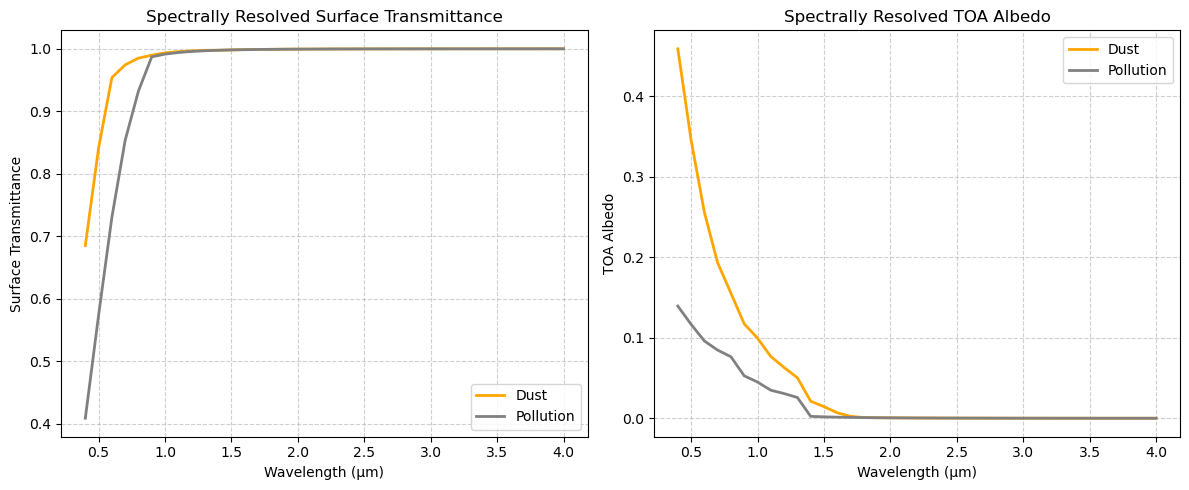

In [21]:
# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Surface Transmittance ---
ax1.plot(wavelengths, spectral_results['dust']['transmittance'], label='Dust', color='orange', linewidth=2)
ax1.plot(wavelengths, spectral_results['pollution']['transmittance'], label='Pollution', color='gray', linewidth=2)
ax1.set_xlabel('Wavelength (µm)')
ax1.set_ylabel('Surface Transmittance')
ax1.set_title('Spectrally Resolved Surface Transmittance')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: TOA Albedo ---
ax2.plot(wavelengths, spectral_results['dust']['albedo'], label='Dust', color='orange', linewidth=2)
ax2.plot(wavelengths, spectral_results['pollution']['albedo'], label='Pollution', color='gray', linewidth=2)
ax2.set_xlabel('Wavelength (µm)')
ax2.set_ylabel('TOA Albedo')
ax2.set_title('Spectrally Resolved TOA Albedo')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

save_path = os.path.join('figures', 'spectral_transmittance_albedo.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Figure successfully saved to: {save_path}")

plt.show()

**What are these plots telling us?**

From our imported CSV data, we observe the single scatter albedo $\omega$ to be generally lower than that of dust. This is because pollution generally has more absorbing components than dust, such as black carbon. We should see that, because of this, the ToA albedo of dust relative to pollution should be higher, and the transmittance of the less-absorbing dust should also be higher. According to the plots, we do in fact see these trends.

Further, dust particles tend to be larger than pollution particles. The size parameter $x = \frac{2\pi r}{\lambda}$ tells us that larger particles scatter longer wavelengths. Thus, the albedo should drop off later for larger particles. Sure enough, ToA albedo for dust reaches 0.0 at longer wavelengths than pollution, meaning that it interacts with (and scatters) larger wavelengths than smaller pollution particles.

As for the asymmetry parameter (g), the data from the CSV files implies no significant difference between dust and pollution for a given wavelength.

### 6.1 - The (next) Model

In [24]:
# --- Section 6.1: Calculate Spectral and Broadband Shortwave Fluxes ---

# 1. Run a "Clean Atmosphere" baseline (tau_a = 0)
clean_transmittance = []
clean_albedo = []

for i, lam in enumerate(wavelengths):
    r_s = rs_spectral[i]
    taus_clean = [0.0, tau_R_055 * (0.55 / lam)**4]  # No aerosols, only Rayleigh
    omegas_clean = [1.0, 1.0] 
    gs_clean = [0.0, 0.0]
    mu0 = 0.5
    
    trans, alb = two_stream_solver(taus_clean, omegas_clean, gs_clean, r_s, mu0)
    clean_transmittance.append(trans)
    clean_albedo.append(alb)

clean_transmittance = np.array(clean_transmittance)
clean_albedo = np.array(clean_albedo)

# Add clean atmosphere to our results dictionary for easy looping
spectral_results['clean'] = {'transmittance': clean_transmittance, 'albedo': clean_albedo}
atmospheres = ['dust', 'pollution', 'clean']

# 2. Interpolate Solar Flux (F0) to our wavelength grid
solar_wave_col = solar_flux.columns[0]
solar_f0_col = solar_flux.columns[1]

# Convert wavelengths from nm to microns (divide by 1000)
solar_waves_um = solar_flux[solar_wave_col].values / 1000.0

# Convert flux from W/m^2/nm to W/m^2/µm (multiply by 1000)
solar_f0_um = solar_flux[solar_f0_col].values * 1000.0

# Interpolate F0 onto our spectral grid
F0_spectral = np.interp(wavelengths, solar_waves_um, solar_f0_um)

# Calculate Downwelling TOA Flux on a horizontal plane (Incident Solar)
F_down_TOA_spec = F0_spectral * mu0 

# Integrate to get the broadband downwelling TOA flux
F_down_TOA_bb = np.trapezoid(F_down_TOA_spec, x=wavelengths)

# 3. Calculate Spectral and Broadband Fluxes for each atmosphere
broadband_fluxes = {}

for atm in atmospheres:
    trans_spec = spectral_results[atm]['transmittance']
    albedo_spec = spectral_results[atm]['albedo']
    
    # --- Calculate Spectrally Resolved Fluxes (W / m^2 / µm) ---
    F_up_TOA_spec = F_down_TOA_spec * albedo_spec
    F_down_SFC_spec = F_down_TOA_spec * trans_spec
    F_up_SFC_spec = F_down_SFC_spec * rs_spectral  # Surface reflection
    
    # --- Integrate to get Broadband SW Fluxes (W / m^2) ---
    # UPDATED to use np.trapezoid instead of np.trapz
    F_up_TOA_bb = np.trapezoid(F_up_TOA_spec, wavelengths)
    F_down_SFC_bb = np.trapezoid(F_down_SFC_spec, wavelengths)
    F_up_SFC_bb = np.trapezoid(F_up_SFC_spec, wavelengths)
    
    # Store the broadband results
    broadband_fluxes[atm] = {
        'F_down_TOA': F_down_TOA_bb,
        'F_up_TOA': F_up_TOA_bb,
        'F_down_SFC': F_down_SFC_bb,
        'F_up_SFC': F_up_SFC_bb,
        
        # Calculate Net Fluxes (Downwelling - Upwelling)
        'Net_TOA': F_down_TOA_bb - F_up_TOA_bb,
        'Net_SFC': F_down_SFC_bb - F_up_SFC_bb
    }

# Print the broadband results
print("--- Section 6.1: Integrated Broadband SW Fluxes (W/m^2) ---")
print(f"Incident TOA Downwelling Flux: {F_down_TOA_bb:.2f} W/m^2\n")

for atm in atmospheres:
    print(f"** {atm.capitalize()} Atmosphere **")
    print(f"  TOA Upwelling:      {broadband_fluxes[atm]['F_up_TOA']:.2f}")
    print(f"  Net TOA Flux:       {broadband_fluxes[atm]['Net_TOA']:.2f}")
    print(f"  Surface Downwelling:{broadband_fluxes[atm]['F_down_SFC']:.2f}")
    print(f"  Net Surface Flux:   {broadband_fluxes[atm]['Net_SFC']:.2f}\n")

--- Section 6.1: Integrated Broadband SW Fluxes (W/m^2) ---
Incident TOA Downwelling Flux: 619.66 W/m^2

** Dust Atmosphere **
  TOA Upwelling:      111.98
  Net TOA Flux:       507.68
  Surface Downwelling:583.21
  Net Surface Flux:   554.27

** Pollution Atmosphere **
  TOA Upwelling:      42.26
  Net TOA Flux:       577.40
  Surface Downwelling:514.41
  Net Surface Flux:   492.07

** Clean Atmosphere **
  TOA Upwelling:      61.11
  Net TOA Flux:       558.55
  Surface Downwelling:588.51
  Net Surface Flux:   558.55



### 6.2 - Verification by Calculating Fluxes and DRE

In [29]:
# --- Section 6.2: Calculate Instantaneous Direct Radiative Effect (DRE) ---

# Note: Ensure the variable 'r_s' (e.g., r_s = 0.1) is defined in your environment 
# from your section setup before running this block.

# 1. Retrieve the pristine/clean sky (p) baseline fluxes
F_up_TOA_p = broadband_fluxes['clean']['F_up_TOA']

# Extract downwelling surface flux for clean sky (handling potential key names)
F_down_SFC_p = broadband_fluxes['clean'].get('F_down_SFC', broadband_fluxes['clean'].get('Net_SFC'))

dre_results = {}
aerosols_to_eval = ['dust', 'pollution']

print("--- Section 6.2: Instantaneous Direct Radiative Effect (W/m^2) ---")

# 2. Calculate DRE for each aerosol using exact definitions from the assignment
for aero in aerosols_to_eval:
    
    # Retrieve aerosol fluxes
    F_up_TOA = broadband_fluxes[aero]['F_up_TOA']
    F_down_SFC = broadband_fluxes[aero].get('F_down_SFC', broadband_fluxes[aero].get('Net_SFC'))
    
    # Eq 3: TOA DRE = F_p^up - F^up
    dre_toa = F_up_TOA_p - F_up_TOA
    
    # Eq 5 & 2: Surface DRE = (F_down_aero - F_down_clean) * (1 - r_s)
    # Explicitly applying the surface reflectance factor as specified in the assignment
    dre_sfc = (F_down_SFC - F_down_SFC_p) * (1 - r_s)
    
    # Eq 7: Atmospheric DRE = TOA DRE - Surface DRE
    dre_atm = dre_toa - dre_sfc  
    
    # Store results
    dre_results[aero] = {
        'DRE_TOA': dre_toa,
        'DRE_SFC': dre_sfc,
        'DRE_ATM': dre_atm
    }
    
    # Print results formatted to 2 decimal places
    print(f"** {aero.capitalize()} Aerosol **")
    print(f"  TOA DRE:        {dre_toa:>8.2f} W/m^2")
    print(f"  Surface DRE:    {dre_sfc:>8.2f} W/m^2")
    print(f"  Atmosphere DRE: {dre_atm:>8.2f} W/m^2\n")

--- Section 6.2: Instantaneous Direct Radiative Effect (W/m^2) ---
** Dust Aerosol **
  TOA DRE:          -50.87 W/m^2
  Surface DRE:       -5.30 W/m^2
  Atmosphere DRE:   -45.57 W/m^2

** Pollution Aerosol **
  TOA DRE:           18.85 W/m^2
  Surface DRE:      -74.10 W/m^2
  Atmosphere DRE:    92.95 W/m^2



**DUST AEROSOL DISCUSSION**

The DRE of the Top of Atmosphere is a difference between net actual radiative flux and clear-sky radiative flux. The equations from our **Definitions** section simplify this down to just upwards flux, but that difference is the physical definition. When ToA DRE is negative, this means that the aerosols are causing the system to lose energy, i.e., a *cooling* effect. We should expect this, as a large part of our atmosphere acts to reflect the sun's energy away *as well as* trap the energy that passes through, lest we end up a scorched desert planet like Mars. 

As for the surface DRE, which is also defined as a difference between net fluxes (real and clear-sky) we also see a cooling effect for dust. This makes sense, as a thicker layer of dust reflects more light (and more *longwave* radiation as well, as found and discussed earlier,) means a cooler surface. 

The resulting atmospheric DRE just represents how much solar energy is actually trapped *within* the aerosol layer. Since we know that dust mostly reflects solar radiation, it makes sense that a dusty aerosol layer has energy flowing out of it, making it a cooler part of the atmosphere. 

**POLLUTION AEROSOL DISCUSSION**

The pollution ToA DRE is positive, which means that *some* aerosols actually have a *warming* effect. For pollution, this makes sense. We know that carbon dioxide in the atmosphere has a warming effect, and here we can see that instead of reflecting solar radiation back to the ToA, it actually absorbs a lot of it.

The negative value of surface DRE means that less energy is reaching the ground. This makes sense, given our figures from before, which show that both albedo *and* transmittance to the surface is quite relatively low for pollution particles. Once again, this shows that our pollution layer is absorbing the solar radiation, and not reflecting or transmitting it.

The resulting (**very**) positive atmospheric DRE confirms that the pollution aerosol layer of the atmosphere is trapping a bunch of solar radiation, making it very warm, as we would expect.

### 6.3 - Questions!

*Note, it seems I may have gotten ahead of myself with trying to assert that the DRE values are reasonable and ended up kind of answering some of the questions here, but for organization's sake, I will reiterate myself*

a. For $\tau_{a,0.55} = 1$, (the value on which this model is run,) the Dust ToA DRE is $-50.87 \frac{W}{m^2}$ and Pollution ToA DRE is $18.85 \frac{W}{m^2}$.  As explored in section 5, dust particles have a higher size parameter than pollution particles (generally), which lead to them scattering (and reflecting) more effectively than pollution particles. The difference in ToA DRE is directly resultant from pollutions much higher absorptance than dust aerosols.

b. The negative value for dust aerosols show a cooling effect, and the positive value for pollution aerosols show a warming effect

c. Based on the atmospheric DRE, dust aerosol layers are cooler than pollution aerosol layers, so the difference in energy (and thus air temperature) would drive convection from polluted layers of the atmosphere to dusty parts of the atmosphere.

d. Let's see:

Running surface reflectance sweep...
Sweep complete! Generating plot...


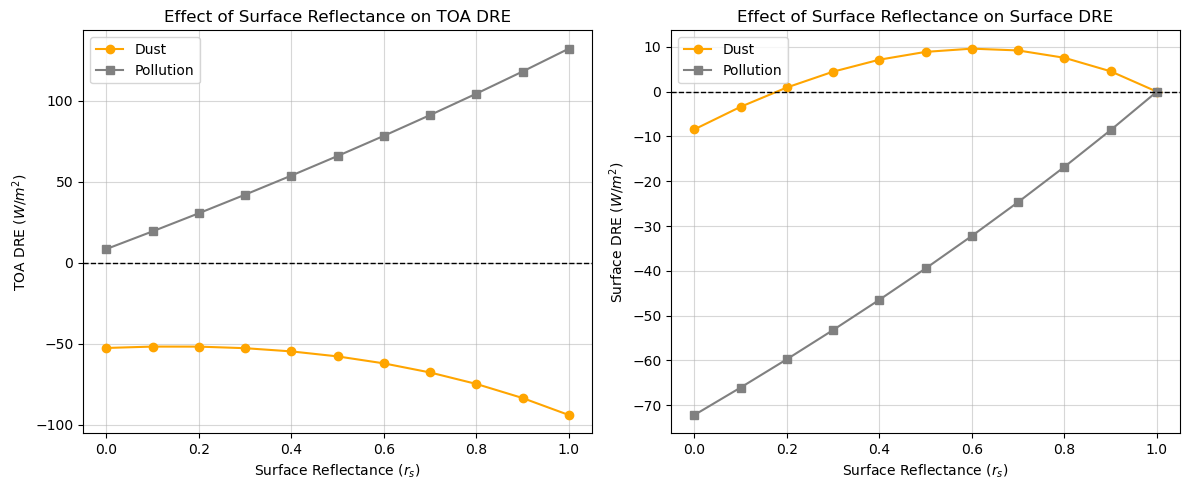

In [27]:
# --- Section 6.3d: Effect of Surface Reflectance on DRE ---

# Define a range of constant surface reflectances to test (0.0 to 1.0)
rs_test_values = np.linspace(0.0, 1.0, 11)

# Dictionaries to store the results
dre_toa_trends = {'dust': [], 'pollution': []}
dre_sfc_trends = {'dust': [], 'pollution': []}

print("Running surface reflectance sweep...")

for rs_constant in rs_test_values:
    bb_fluxes_test = {}
    
    # Evaluate Clean, Dust, and Pollution for this specific r_s
    for atm in ['clean', 'dust', 'pollution']:
        trans_spec = []
        alb_spec = []
        
        # Spectral Loop
        for i, lam in enumerate(wavelengths):
            # Clean
            if atm == 'clean':
                tau = [0.0, tau_R_055 * (0.55 / lam)**4]
                omega = [1.0, 1.0]
                g = [0.0, 0.0]
            # Aerosols
            else:
                ext_norm = np.interp(lam, aerosol_props['lambda (mu)'], aerosol_props[f'{atm} Be'])
                tau = [tau_a_055 * ext_norm, tau_R_055 * (0.55 / lam)**4]
                omega = [np.interp(lam, aerosol_props['lambda (mu)'], aerosol_props[f'{atm} omega']), 1.0]
                g = [np.interp(lam, aerosol_props['lambda (mu)'], aerosol_props[f'{atm} g']), 0.0]
            
            # Solve for this wavelength and constant r_s
            t, a = two_stream_solver(tau, omega, g, rs_constant, mu0=0.5)
            trans_spec.append(t)
            alb_spec.append(a)
            
        trans_spec = np.array(trans_spec)
        alb_spec = np.array(alb_spec)
        
        # Calculate broadband fluxes
        F_up_TOA_spec = F_down_TOA_spec * alb_spec
        F_down_SFC_spec = F_down_TOA_spec * trans_spec
        Net_SFC_spec = F_down_SFC_spec * (1.0 - rs_constant)
        
        bb_fluxes_test[atm] = {
            'F_up_TOA': np.trapezoid(F_up_TOA_spec, x=wavelengths),
            'Net_SFC': np.trapezoid(Net_SFC_spec, x=wavelengths)
        }
        
    # Calculate DREs for this r_s
    for aero in ['dust', 'pollution']:
        dre_toa = bb_fluxes_test['clean']['F_up_TOA'] - bb_fluxes_test[aero]['F_up_TOA']
        dre_sfc = bb_fluxes_test[aero]['Net_SFC'] - bb_fluxes_test['clean']['Net_SFC']
        
        dre_toa_trends[aero].append(dre_toa)
        dre_sfc_trends[aero].append(dre_sfc)

print("Sweep complete! Generating plot...")

# --- Plot the Results ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# TOA DRE Plot
ax1.plot(rs_test_values, dre_toa_trends['dust'], label='Dust', color='orange', marker='o')
ax1.plot(rs_test_values, dre_toa_trends['pollution'], label='Pollution', color='gray', marker='s')
ax1.axhline(0, color='black', linestyle='--', linewidth=1)
ax1.set_xlabel('Surface Reflectance ($r_s$)')
ax1.set_ylabel('TOA DRE ($W/m^2$)')
ax1.set_title('Effect of Surface Reflectance on TOA DRE')
ax1.legend()
ax1.grid(True, alpha=0.5)

# Surface DRE Plot
ax2.plot(rs_test_values, dre_sfc_trends['dust'], label='Dust', color='orange', marker='o')
ax2.plot(rs_test_values, dre_sfc_trends['pollution'], label='Pollution', color='gray', marker='s')
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Surface Reflectance ($r_s$)')
ax2.set_ylabel('Surface DRE ($W/m^2$)')
ax2.set_title('Effect of Surface Reflectance on Surface DRE')
ax2.legend()
ax2.grid(True, alpha=0.5)

plt.tight_layout()
plt.savefig('figures/surface_reflectance_dre.png', dpi=300, bbox_inches='tight')
plt.show()